<div style="text-align: center; font-size: 40px; font-weight: bold;">
    Train Model Deeplabv3+ Architecture
</div>

# Libraries

In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, mixed_precision, backend as K
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt

In [2]:
# Aktifkan memory growth agar tidak langsung habiskan VRAM
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✅ GPU detected and memory growth enabled.")
    except RuntimeError as e:
        print(e)
else:
    print("⚠️ No GPU detected, using CPU.")

# Gunakan mixed precision (hemat memori GPU)
mixed_precision.set_global_policy('mixed_float16')
print("✅ Mixed precision enabled (float16).")

✅ GPU detected and memory growth enabled.
INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 3070, compute capability 8.6
✅ Mixed precision enabled (float16).


In [3]:
def iou_metric(y_true, y_pred, smooth: float = 1e-6) -> float:
    """
    Computes the Intersection over Union (IoU) metric.
    
    Args:
        y_true: Ground truth binary mask.
        y_pred: Predicted binary mask.
        smooth (float): Smoothing factor to avoid division by zero.
    
    Returns:
        float: IoU score.
    """
    y_pred = K.cast(y_pred > 0.5, dtype='float32')
    intersection = K.sum(y_true * y_pred)
    union = K.sum(y_true) + K.sum(y_pred) - intersection
    return (intersection + smooth) / (union + smooth)

In [4]:
IMG_SIZE = (256, 256)

def load_image(img_path, mask_path):
    # ----- image -----
    img = tf.io.read_file(img_path)
    img = tf.image.decode_bmp(img, channels=3)   # gambar input RGB
    img = tf.image.resize(img, (256, 256))
    img = tf.cast(img, tf.float32) / 255.0

    # ----- mask -----
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_bmp(mask, channels=0)   # biarkan sesuai file
    mask = tf.image.resize(mask, (256, 256), method="nearest")
    
    # pastikan hanya 1 channel
    if tf.shape(mask)[-1] != 1:
        mask = tf.image.rgb_to_grayscale(mask)

    # ubah ke {0,1}
    mask = tf.cast(mask > 127, tf.float32)

    return img, mask

def make_dataset(img_dir, mask_dir, batch_size=4, shuffle=True):
    img_files = sorted([os.path.join(img_dir, f) for f in os.listdir(img_dir)])
    mask_files = sorted([os.path.join(mask_dir, f) for f in os.listdir(mask_dir)])
    ds = tf.data.Dataset.from_tensor_slices((img_files, mask_files))
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(buffer_size=100)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset("Data_split/train/images", "Data_split/train/masks", batch_size=8)
val_ds   = make_dataset("Data_split/valid/images", "Data_split/valid/masks", batch_size=8, shuffle=False)

In [5]:
def DeepLabV3Plus_ResNet50(input_shape=(256, 256, 3), num_classes=1):
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)

    # Encoder feature maps
    high_level_feature = base_model.get_layer('conv4_block6_out').output  # stride 16
    low_level_feature = base_model.get_layer('conv2_block3_out').output   # stride 4

    # ASPP Module
    def ASPP(x):
        y1 = layers.Conv2D(256, 1, padding="same", use_bias=False)(x)
        y1 = layers.BatchNormalization()(y1)
        y1 = layers.Activation("relu")(y1)

        y2 = layers.Conv2D(256, 3, dilation_rate=6, padding="same", use_bias=False)(x)
        y2 = layers.BatchNormalization()(y2)
        y2 = layers.Activation("relu")(y2)

        y3 = layers.Conv2D(256, 3, dilation_rate=12, padding="same", use_bias=False)(x)
        y3 = layers.BatchNormalization()(y3)
        y3 = layers.Activation("relu")(y3)

        y4 = layers.Conv2D(256, 3, dilation_rate=18, padding="same", use_bias=False)(x)
        y4 = layers.BatchNormalization()(y4)
        y4 = layers.Activation("relu")(y4)

        y5 = layers.GlobalAveragePooling2D()(x)
        y5 = layers.Reshape((1, 1, y5.shape[-1]))(y5)
        y5 = layers.Conv2D(256, 1, padding="same", use_bias=False)(y5)
        y5 = layers.BatchNormalization()(y5)
        y5 = layers.Activation("relu")(y5)
        y5 = layers.UpSampling2D(size=(input_shape[0] // 16, input_shape[1] // 16),
                                 interpolation="bilinear")(y5)

        y = layers.Concatenate()([y1, y2, y3, y4, y5])
        y = layers.Conv2D(256, 1, padding="same", use_bias=False)(y)
        y = layers.BatchNormalization()(y)
        y = layers.Activation("relu")(y)
        return y

    x = ASPP(high_level_feature)

    # Decoder
    x = layers.UpSampling2D(size=(4, 4), interpolation="bilinear")(x)

    low_level_feature = layers.Conv2D(48, 1, padding="same", use_bias=False)(low_level_feature)
    low_level_feature = layers.BatchNormalization()(low_level_feature)
    low_level_feature = layers.Activation("relu")(low_level_feature)

    x = layers.Concatenate()([x, low_level_feature])

    x = layers.Conv2D(256, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv2D(256, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.UpSampling2D(size=(4, 4), interpolation="bilinear")(x)
    outputs = layers.Conv2D(num_classes, 1, activation="sigmoid", dtype="float32")(x)

    model = models.Model(inputs=base_model.input, outputs=outputs)
    return model

model = DeepLabV3Plus_ResNet50(input_shape=(256, 256, 3), num_classes=1)
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 256, 256, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 262, 262, 3)  0           ['input_1[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 128, 128, 64  9472        ['conv1_pad[0][0]']              
                                )                                                                 
                                                                                              

In [6]:
# ======= Callbacks =======
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

lr_reduce = ReduceLROnPlateau(monitor='val_loss', 
                              factor=0.5, 
                              patience=5, 
                              min_lr=1e-6,
                              verbose=1)

model_checkpoint = ModelCheckpoint('Model/model_DeeplabV3+.h5', 
                                   monitor='val_loss', 
                                   save_best_only=True, 
                                   verbose=1)

callbacks = [early_stop, lr_reduce, model_checkpoint]

model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
               loss="binary_crossentropy",
               metrics=["accuracy", iou_metric])

In [7]:
history = model.fit(train_ds, validation_data=val_ds, epochs=100, callbacks=callbacks)

Epoch 1/100
75/75 [==============================] - ETA: 0s - loss: 0.2543 - accuracy: 0.9087 - iou_metric: 0.2284
Epoch 1: val_loss improved from inf to 78.71146, saving model to Model\model_DeeplabV3+.h5
75/75 [==============================] - 27s 149ms/step - loss: 0.2543 - accuracy: 0.9087 - iou_metric: 0.2284 - val_loss: 78.7115 - val_accuracy: 0.0902 - val_iou_metric: 0.0901 - lr: 1.0000e-04
Epoch 2/100
75/75 [==============================] - ETA: 0s - loss: 0.1777 - accuracy: 0.9314 - iou_metric: 0.3147
Epoch 2: val_loss did not improve from 78.71146
75/75 [==============================] - 9s 116ms/step - loss: 0.1777 - accuracy: 0.9314 - iou_metric: 0.3147 - val_loss: 277.4519 - val_accuracy: 0.1074 - val_iou_metric: 0.0901 - lr: 1.0000e-04
Epoch 3/100
75/75 [==============================] - ETA: 0s - loss: 0.1697 - accuracy: 0.9333 - iou_metric: 0.3393
Epoch 3: val_loss did not improve from 78.71146
75/75 [==============================] - 9s 114ms/step - loss: 0.1697 - a

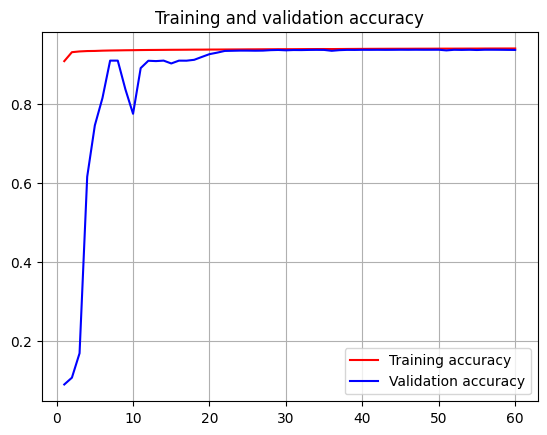

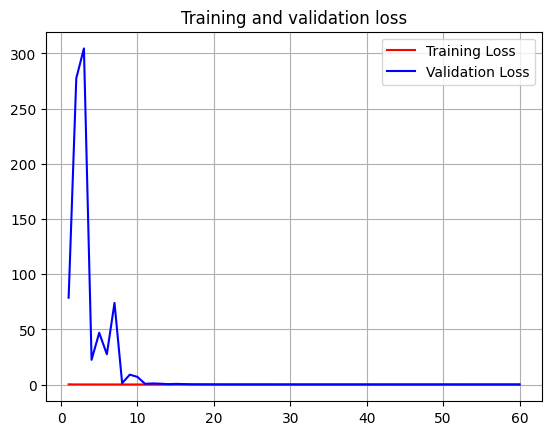

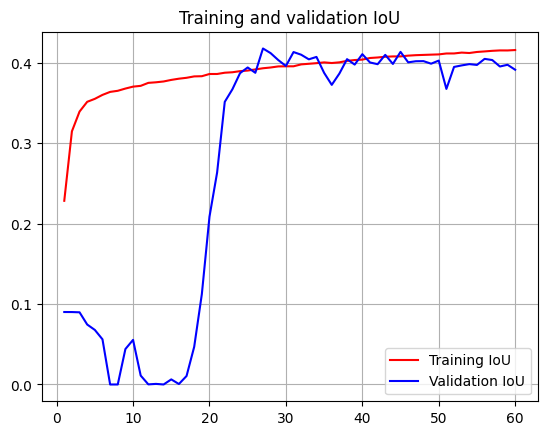

In [8]:
# Extract data from history.history
epochs = range(1, len(history.history['loss']) + 1)
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
iou = history.history['iou_metric']
val_iou = history.history['val_iou_metric']

# Plotting Training and Validation Accuracy
plt.plot(epochs, acc, 'r', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend()
plt.grid(True)
plt.show()  # Display accuracy plot

# Plotting Training and Validation Loss
plt.figure()
plt.plot(epochs, loss, 'r', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation Loss')
plt.title('Training and validation loss')
plt.legend()
plt.grid(True)
plt.show()  # Display loss plot

# Plotting Training and Validation IoU
plt.figure()
plt.plot(epochs, iou, 'r', label='Training IoU')
plt.plot(epochs, val_iou, 'b', label='Validation IoU')
plt.title('Training and validation IoU')
plt.legend()
plt.grid(True)
plt.show()  # Display IoU plot

In [9]:
# Hitung rata-rata untuk setiap metrik
avg_acc = np.mean(history.history['accuracy'])
avg_val_acc = np.mean(history.history['val_accuracy'])

avg_loss = np.mean(history.history['loss'])
avg_val_loss = np.mean(history.history['val_loss'])

avg_iou = np.mean(history.history['iou_metric'])
avg_val_iou = np.mean(history.history['val_iou_metric'])

# Cetak hasil rata-rata
print("=== Average Results Training ===")
print(f"Average Training Accuracy   : {avg_acc:.4f}")
print(f"Average Validation Accuracy : {avg_val_acc:.4f}")
print(f"Average Training Loss       : {avg_loss:.4f}")
print(f"Average Validation Loss     : {avg_val_loss:.4f}")
print(f"Average Training IoU        : {avg_iou:.4f}")
print(f"Average Validation IoU      : {avg_val_iou:.4f}")

=== Average Results Training ===
Average Training Accuracy   : 0.9381
Average Validation Accuracy : 0.8757
Average Training Loss       : 0.1505
Average Validation Loss     : 14.3412
Average Training IoU        : 0.3890
Average Validation IoU      : 0.2785
